## Doble for-løkker (nested for-loops)
Ofte vil vi trenge å variere to variabler i programmet vårt. La oss si at vi vil skrive ut den komplette (lille) gangetabellen: 

In [1]:
for i in range (1,11):
    for j in range(1,11):
        print(i*j, end = "      ")
    print("\t")

1      2      3      4      5      6      7      8      9      10      	
2      4      6      8      10      12      14      16      18      20      	
3      6      9      12      15      18      21      24      27      30      	
4      8      12      16      20      24      28      32      36      40      	
5      10      15      20      25      30      35      40      45      50      	
6      12      18      24      30      36      42      48      54      60      	
7      14      21      28      35      42      49      56      63      70      	
8      16      24      32      40      48      56      64      72      80      	
9      18      27      36      45      54      63      72      81      90      	
10      20      30      40      50      60      70      80      90      100      	


Et naturlig spørsmål er hvordan man kan lagre hele den lille gangetabellen i en variabel i python. Et svar er lister av lister. 

In [2]:
gangetabellen = []
for i in range (0,11):
    temp_list = [] #For hver i lager vi oss en midlertidig liste
    for j in range(1,11):
        temp_list.append(i*j) #Vi legger til gangetabellen for i
    gangetabellen.append(temp_list) #Vi legger gangetabellen for i til hele listen vår når den er ferdig
print(gangetabellen[7][8])   

63


La oss si at vi har kundedata for en person med flere konti i banken vår. Det kan vi også løse ved å bruke lister av lister.

In [3]:
kontoinnehaver = "Lisa Bjerke"
saldo_1 = 23244.56
saldo_2 = 34545.00
saldo_3 = 37455.00
alder = 37
viktig = False

kontoinfo_liste = [kontoinnehaver, [saldo_1,saldo_2, saldo_3], alder, viktig]
print(kontoinfo_liste)



['Lisa Bjerke', [23244.56, 34545.0, 37455.0], 37, False]


## Mer om numpy
Egenskapene til numpy arrays gjør at vi kan slippe mange for looper sammenlignet med når vi jobber med lister. Beregninger med numpy arrays er også mye raskere enn med lister. I motsetning til lister kan ikke elementer i numpy arrays være av forskjellig datatype.Det finnes flere måter å lage numpy arrays på https://numpy.org/doc/stable/user/basics.creation.html. Ofte trenger vi numpy.linspace. np.linspace(start,stop,n) lager n verdier mellom start og stop. La oss se på hvordan vi kan løse noe vi gjorde i går med numpy arrays:

In [12]:
#Husk det vi så i går.
import numpy as np
a = np.ones(10)
b = np.linspace(1,10,10)
e =[1,2,3,4,5,6,7,8,9]
#print(2 * a)
#print(a**2)
#print(b)
print(b**2)
#Leg merke til at vi har gjort operasjoner på array uten å bruke løkker
print(b)
#print(e**2)
#for i in range(10):
#    print(e**2)


[  1.   4.   9.  16.  25.  36.  49.  64.  81. 100.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


In [8]:

import numpy as np

#Dette gjorde vi i går.
def penge_forskjell(rente_1, rente_2,startsum, antall_år):
    forskjell_liste = []#Før vi fyller listen må vi lage en tom liste
    sum_1 = startsum
    sum_2 = startsum
    for i in range(antall_år):
        sum_1 = sum_1*rente_1
        sum_2 = sum_2*rente_2
        forskjell_liste.append(round(sum_2-sum_1,2))
    return forskjell_liste
forskjell_test = penge_forskjell(1.01, 1.05, 250000,10)
print(forskjell_test)

#Her er et alternativ fremgangsmåte ved å bruke numpy arrays.
#Legg merke til at det ikke er brukt for løkker. 
def penge_forskjell_np(rente_1, rente_2,startsum, antall_år):
    years = np.linspace(0,antall_år)#Vi lager et numpy array for årene
    sum_1 = startsum*rente_1**years
    sum_2 = startsum*rente_2**years
    return (sum_2 - sum_1)

print(penge_forskjell_np(1.01, 1.05, 250000,10))



[10000.0, 20600.0, 31831.0, 43725.56, 56317.88, 69643.87, 83741.27, 98649.68, 114410.74, 131068.13]
[     0.           1993.54274856   4011.08706798   6052.88137733
   8119.17659832  10210.2261804   12326.28612607  14467.61501648
  16634.47403726  18827.1270046   21045.84039165  23290.88335511
  25562.52776212  27861.04821743  30186.72209082  32539.82954483
  34920.65356268  37329.4799766   39766.59749634  42232.29773801
  44726.87525319  47250.62755833  49803.8551645   52386.86160733
  54999.95347738  57643.44045068  60317.63531967  63022.85402444
  65759.41568425  68527.64262934  71327.86043317  74160.39794486
  77025.58732203  79923.7640639   82855.26704484  85820.43854811
  88819.62430005  91853.17350456  94921.43887793  98024.77668403
 101163.54676985 104338.11260138 107548.84129989 110796.10367851
 114080.27427921 117401.73141021 120760.85718364 124158.03755365
 127593.66235493 131068.12534156]





La oss nå se på eksempelet med en populasjonsmodel:

In [30]:

#Folketall på Island

e = 2.71828 #Eulers tall (Vi skal se en bedre måte å hente slike konstanter)
K = 4e6 #Maksimal populasjon
r = 0.02 #Relativ vekstrate
start = 2021 #Startår
slutt = 2240 #Sluttår
P0 = 372520 #Startpopulasjon

print("Ved år", start, "var innbyggertallet på Island", P0)
print("Vi antar en årlig vekstrate på", r*100, "%")

tid = np.linspace(0,start-slutt) #lang tid mellom startår og sluttår
A = (K-P0)/P0   #Koeffisient fra formel

populasjon = ( K/(1+A*e**(-r*tid))) #Populasjon i år 2040 - som heltall
#print(populasjon)

#opulasjon_avrundet4 = round(populasjon_2040,-3)

#print("test", populasjon_avrundet4)

#print(tid, "år senere, i", slutt, "vil populasjon være", populasjon_avrundet4)
#rint(tid, "år senere, i", slutt, "vil populasjon være omtrent", populasjon_2040//1000, "tusen")

Ved år 2021 var innbyggertallet på Island 372520
Vi antar en årlig vekstrate på 2.0 %


42
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


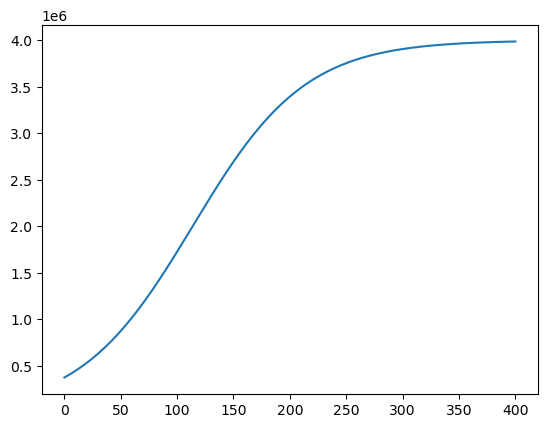

In [36]:
def f(x):
    return x**2-3*x+2
print(f(8))
verdier= np.linspace(0,10,11)
print(verdier)
funksjons_verdier = f(verdier)
import matplotlib.pyplot as plt
#plt.plot(verdier, funksjons_verdier)
#plt.show()
tid = np.linspace(0,400,201) #lang tid mellom startår og sluttår

A = (K-P0)/P0   #Koeffisient fra formel

populasjon = ( K/(1+A*e**(-r*tid)))
plt.plot(tid,populasjon)
plt.show()

Vi vil ha et numpy array med populasjonen etter hvert år. Da trenger vi å fore et numpy array for tiden inn i funksjonen vår. Oppgaven deres er å lage et numpy array for populasjonen på Island etter denne modellen i alle år fra og med 2021 til og med 2040.  

In [28]:
#Folketall på Island

e = np.e #Eulers tall (Vi skal se en bedre måte å hente slike konstanter)
K = 4e6 #Maksimal populasjon
r = 0.02 #Relativ vekstrate
start = 2021 #Startår
slutt = 2240 #Sluttår
P0 = 372520 #Startpopulasjon
print("Ved år", start, "var innbyggertallet på Island", P0)
print("Vi antar en årlig vekstrate på", r*100, "%")

#Din kode her:



Ved år 2021 var innbyggertallet på Island 372520
Vi antar en årlig vekstrate på 2.0 %



Vi har sett før at det kan være lurt å bruke listeslicing med lister. Ved bruk av numpy arrays er fordelene ved slicing mange.

In [ ]:
#Vi trekker listen fra og med det andre året til og med det siste året fra listen fra og med 
#det første året til og med det nest siste året. 

populasjonsøkning = populasjon[1:]-populasjon[:-1] 
print(populasjonsøkning)


I stedet for lister av lister, er det ofte best å bruke todimensjonale numpy array. 


In [42]:
a = np.eye(2)
b= np.zeros((2,2)) #Legg merke til to parenteser
c = np.zeros((10,10))
#print(a)
print(b)
b[0,1]= 7
#print(b)
print(c)
c[4,8] = 3
print(c)

[[0. 0.]
 [0. 0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


Oppgave: Fyll et numpy array med den lille gangetabellen. (Doble for-løkker er lov.)

In [ ]:
#Din kode her


## Matplotlib
Visualisering av data er en veldig viktig del av databehandling. Et viktig hjelpemidel er matplotlib og pyplot. https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html


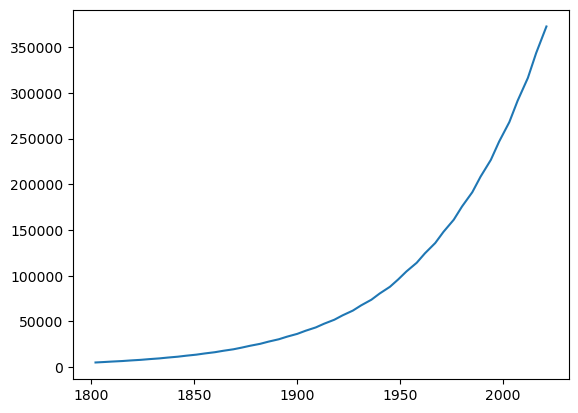

In [31]:
import matplotlib.pyplot as plt
plt.plot((tid + start).astype(int), populasjon)
plt.show()

In [ ]:
Det finnes mye man kan gjøre for å få en graf til å se finere ut.  

In [ ]:
plt.plot(tid + start, populasjon)
plt.xlabel("Årstall")
plt.ylabel("Innbyggere")
plt.title("Projeksjon for Innbyggertall på Island")
plt.show()

Oppgave til dere: Bruk funksjonen pengeforskjell_np over til å lage en graf over forskjellen mellom to kontobeholdninger. 

In [ ]:
#Din kode her